In [36]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.express as px

mpl.rcParams['figure.figsize'] = (10,8)
mpl.rcParams['axes.grid'] = False


In [37]:
df = pd.read_csv('dataset\Raw_data_1Hr_2015_2024_Mandir_Marg_Delhi_DPCC.csv')

In [38]:
df.head()

,Timestamp,PM2.5,PM10,NO,NO2,NH3,SO2,CO,Ozone,AT,RH,WS,WD,SR,BP
0,01-01-2015 0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,01-01-2015 1.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,01-01-2015 2.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,01-01-2015 3.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,01-01-2015 4.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [39]:
df['Timestamp'] = pd.to_datetime(df['Timestamp'], format="%d-%m-%Y %H.%M") #datetime setup

In [40]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 87672 entries, 0 to 87671
Data columns (total 15 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Timestamp  87672 non-null  datetime64[ns]
 1   PM2.5      76973 non-null  float64       
 2   PM10       77234 non-null  float64       
 3   NO         75595 non-null  float64       
 4   NO2        76555 non-null  float64       
 5   NH3        75934 non-null  float64       
 6   SO2        74546 non-null  float64       
 7   CO         75144 non-null  float64       
 8   Ozone      75821 non-null  float64       
 9   AT         77414 non-null  float64       
 10  RH         77508 non-null  float64       
 11  WS         78462 non-null  float64       
 12  WD         77639 non-null  float64       
 13  SR         78021 non-null  float64       
 14  BP         78037 non-null  float64       
dtypes: datetime64[ns](1), float64(14)
memory usage: 10.0 MB


In [41]:
df.head()

,Timestamp,PM2.5,PM10,NO,NO2,NH3,SO2,CO,Ozone,AT,RH,WS,WD,SR,BP
0,2015-01-01 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2015-01-01 01:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2015-01-01 02:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2015-01-01 03:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2015-01-01 04:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [42]:
fig = px.line(df, x='Timestamp', y='PM2.5', title='PM2.5 trend')

fig.update_xaxes(
    rangeslider_visible = True,
    rangeselector=dict(
        buttons=list([
            dict(count=1, label='1y', step='year', stepmode='backward'),
            dict(count=2, label='3y', step='year', stepmode='backward'),
            dict(count=3, label='5y', step='year', stepmode='backward'),
            dict(step='all')
        ])
    )
)
fig.show()

In [43]:
ny_df=df.set_index('Timestamp')

array([<Axes: xlabel='Timestamp'>, <Axes: xlabel='Timestamp'>,
       <Axes: xlabel='Timestamp'>, <Axes: xlabel='Timestamp'>,
       <Axes: xlabel='Timestamp'>, <Axes: xlabel='Timestamp'>,
       <Axes: xlabel='Timestamp'>, <Axes: xlabel='Timestamp'>,
       <Axes: xlabel='Timestamp'>, <Axes: xlabel='Timestamp'>,
       <Axes: xlabel='Timestamp'>, <Axes: xlabel='Timestamp'>,
       <Axes: xlabel='Timestamp'>, <Axes: xlabel='Timestamp'>],
      dtype=object)

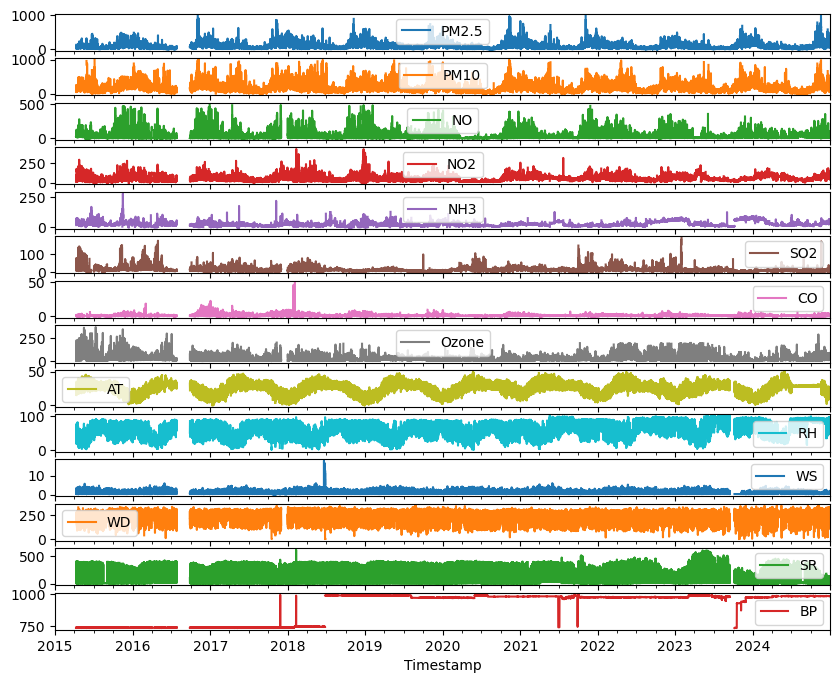

In [44]:
ny_df.plot(subplots=True)

In [45]:
ny_df = ny_df.resample('D').mean()

array([<Axes: xlabel='Timestamp'>, <Axes: xlabel='Timestamp'>,
       <Axes: xlabel='Timestamp'>, <Axes: xlabel='Timestamp'>,
       <Axes: xlabel='Timestamp'>, <Axes: xlabel='Timestamp'>,
       <Axes: xlabel='Timestamp'>, <Axes: xlabel='Timestamp'>,
       <Axes: xlabel='Timestamp'>, <Axes: xlabel='Timestamp'>,
       <Axes: xlabel='Timestamp'>, <Axes: xlabel='Timestamp'>,
       <Axes: xlabel='Timestamp'>, <Axes: xlabel='Timestamp'>],
      dtype=object)

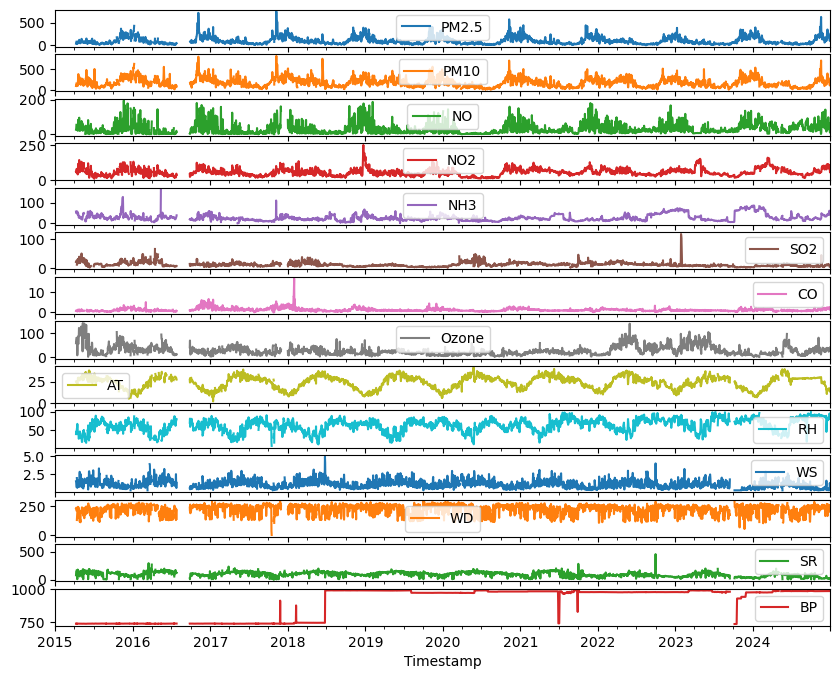

In [46]:
ny_df.plot(subplots=True)

### Prophet model

In [47]:

from prophet import Prophet

In [48]:
ny_df = ny_df.reset_index()[['Timestamp', 'PM2.5']].rename({'Timestamp':'ds','PM2.5':'y'}, axis='columns')

In [14]:
ny_df

,ds,y
0,2015-01-01,NaN
1,2015-01-02,NaN
2,2015-01-03,NaN
3,2015-01-04,NaN
4,2015-01-05,NaN
...,...,...
3648,2024-12-27,152.954545
3649,2024-12-28,104.933333
3650,2024-12-29,98.541667
3651,2024-12-30,95.863636


<Axes: >

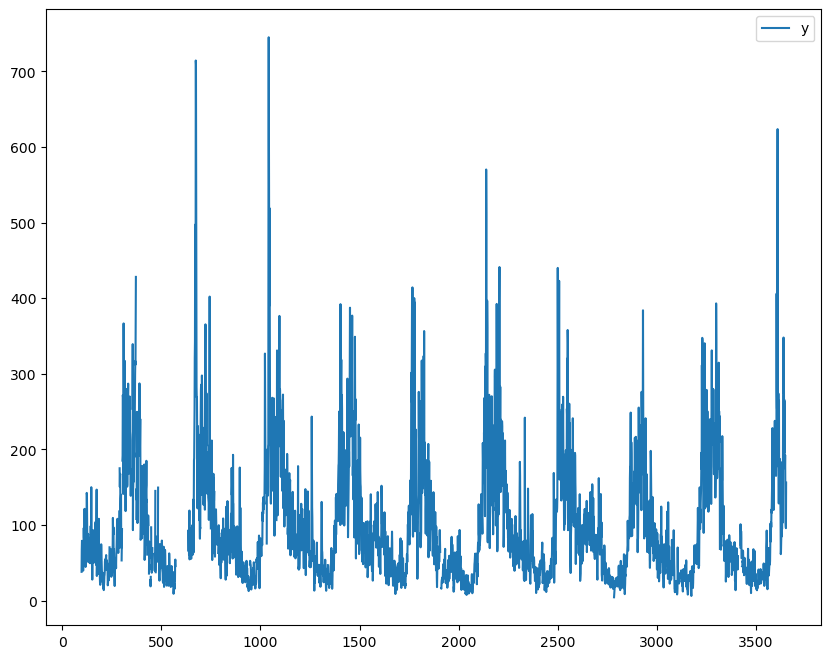

In [55]:
ny_df[['y']].plot()

In [15]:
train = ny_df[(ny_df['ds'] >= '2015-01-01')&(ny_df['ds']<= '2023-12-31')]
test = ny_df[(ny_df['ds']>'2023-12-31')]

In [16]:
train.shape

(3287, 2)

In [17]:
test.shape

(366, 2)

In [18]:
test

,ds,y
3287,2024-01-01,177.757083
3288,2024-01-02,167.170000
3289,2024-01-03,181.753750
3290,2024-01-04,219.968750
3291,2024-01-05,174.920000
...,...,...
3648,2024-12-27,152.954545
3649,2024-12-28,104.933333
3650,2024-12-29,98.541667
3651,2024-12-30,95.863636


In [ ]:
m = Prophet(interval_width=0.8,yearly_seasonality=True)

In [56]:
m.seasonalities

OrderedDict([('yearly',
              {'period': 365.25,
               'fourier_order': 10,
               'prior_scale': 10.0,
               'mode': 'additive',
               'condition_name': None}),
             ('weekly',
              {'period': 7,
               'fourier_order': 3,
               'prior_scale': 10.0,
               'mode': 'additive',
               'condition_name': None})])

In [20]:
m.fit(train)

16:14:01 - cmdstanpy - INFO - Chain [1] start processing
16:14:03 - cmdstanpy - INFO - Chain [1] done processing


In [21]:
m.params

OrderedDict([('lp__', array([[6832.93]])),
             ('k', array([[0.00852304]])),
             ('m', array([[0.138574]])),
             ('delta',
              array([[-8.04468e-08,  3.34545e-07, -3.35954e-08,  4.82083e-02,
                       1.85882e-05,  1.09063e-06, -4.66597e-08, -3.06890e-07,
                      -9.62079e-02, -6.85641e-02, -2.71745e-05, -4.35663e-05,
                      -2.86882e-03, -9.26717e-07, -4.10499e-08,  3.22690e-07,
                       1.24691e-01,  3.09685e-02,  1.04917e-07, -5.23969e-03,
                      -8.23812e-02, -6.01508e-07,  2.60506e-07,  1.52338e-07,
                       2.17495e-07]])),
             ('sigma_obs', array([[0.0651047]])),
             ('beta',
              array([[-1.26101e-02,  9.92909e-02, -4.57596e-02,  3.12259e-02,
                      -6.51561e-03, -3.49533e-03,  1.28988e-02, -1.06979e-02,
                       1.63239e-02,  5.92698e-03,  5.59570e-03,  1.76127e-02,
                      -2.54340e-03, 

In [ ]:
# creating future dates for 365 days
future = m.make_future_dataframe(periods=366)
future.tail()

,ds
3648,2024-12-27
3649,2024-12-28
3650,2024-12-29
3651,2024-12-30
3652,2024-12-31


In [59]:
forecast = m.predict(future)
# forecast[['ds','yhat','yhat_lower','yhat_upper']].tail()
forecast.head()



,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,weekly,weekly_lower,weekly_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2015-01-01,103.051084,161.371063,283.368369,103.051084,103.051084,116.174865,116.174865,116.174865,2.321104,2.321104,2.321104,113.853761,113.853761,113.853761,0.0,0.0,0.0,219.225949
1,2015-01-02,103.053076,153.428734,273.691329,103.053076,103.053076,113.965036,113.965036,113.965036,1.795428,1.795428,1.795428,112.169607,112.169607,112.169607,0.0,0.0,0.0,217.018112
2,2015-01-03,103.055068,146.869940,279.657587,103.055068,103.055068,109.780383,109.780383,109.780383,-0.490322,-0.490322,-0.490322,110.270705,110.270705,110.270705,0.0,0.0,0.0,212.835451
3,2015-01-04,103.057060,148.204204,271.630073,103.057060,103.057060,106.771360,106.771360,106.771360,-1.415039,-1.415039,-1.415039,108.186399,108.186399,108.186399,0.0,0.0,0.0,209.828419
4,2015-01-05,103.059052,144.216190,264.233066,103.059052,103.059052,103.707541,103.707541,103.707541,-2.237449,-2.237449,-2.237449,105.944990,105.944990,105.944990,0.0,0.0,0.0,206.766593


<Axes: xlabel='ds'>

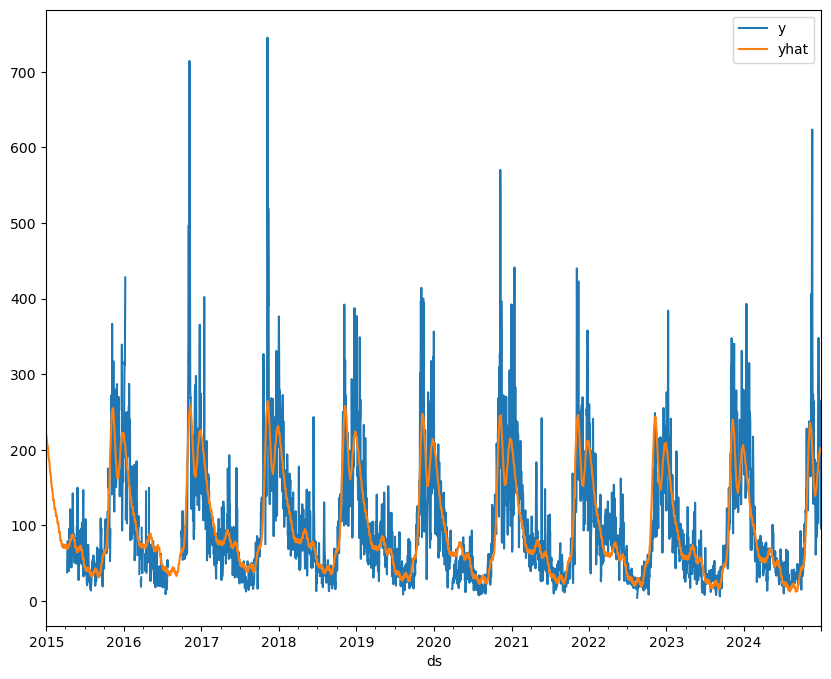

In [24]:
pd.concat([ny_df.set_index('ds')['y'],forecast.set_index('ds')['yhat']],axis=1).plot()

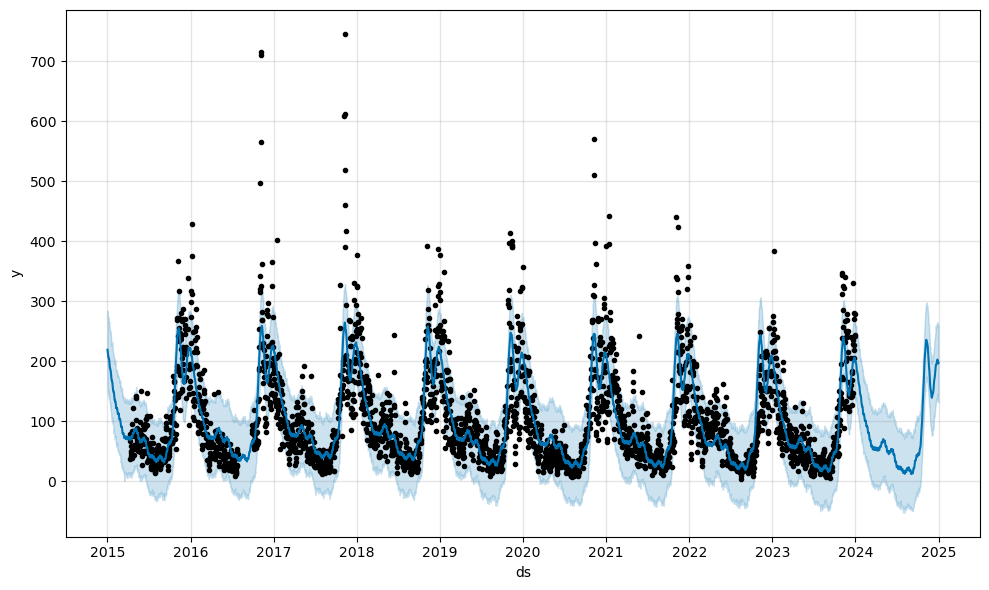

In [25]:
fig1 = m.plot(forecast)

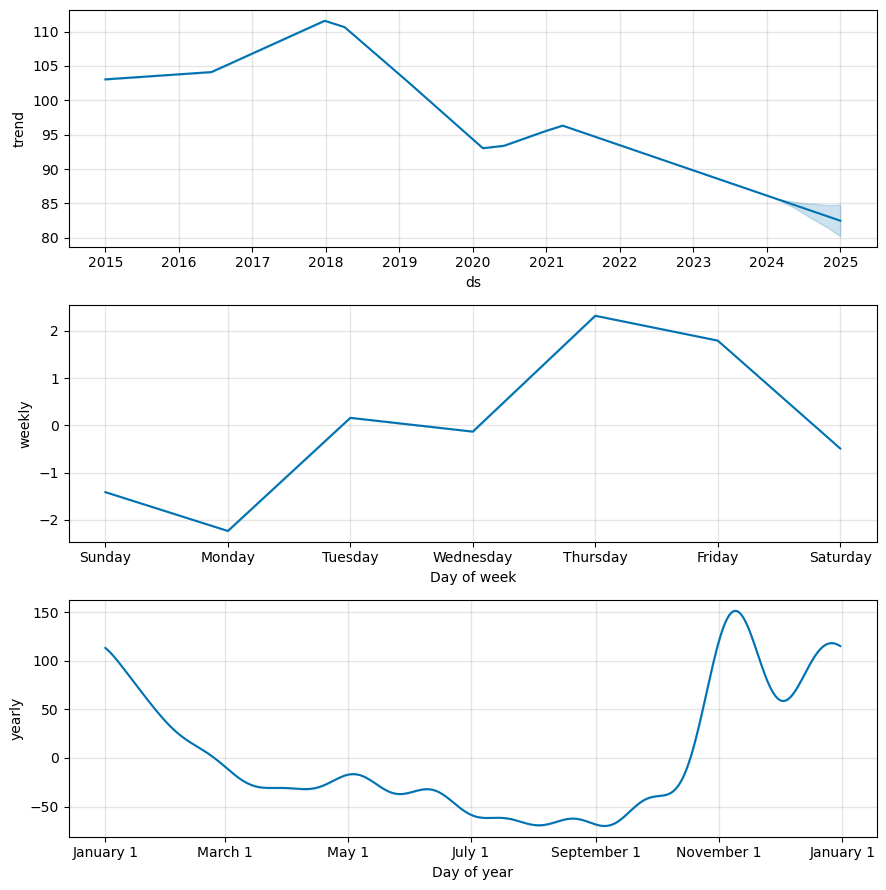

In [26]:
fig2 = m.plot_components(forecast)

In [27]:
from prophet.plot import plot_plotly
import plotly.offline as py

fig = plot_plotly(m, forecast) #this returns a plotly figure
py.iplot(fig)